In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

# 1. Inefficient Data Choice
# Using the 30-second dataset provides much fewer training examples (only 1000)
# Path to your GTZAN features (adjust folder name if different)
path = "/content/drive/MyDrive/archive/Data/go_emotions_dataset.csv"

# Loading the dataset
df = pd.read_csv(path).sample(500)

# Optimization: Drop the 'filename' immediately as it's a string and
# isn't useful for the math behind genre classification
if 'filename' in df.columns:
    df = df.drop(columns=['filename'])

print("Music Data Loaded. Total Samples:", df.shape[0])
df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Music Data Loaded. Total Samples: 500


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
112733,edddmgg,ISU was missing players and had to choke that ...,False,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
125803,edx5avp,I thought he was a candidate as a [NAME] when ...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
203037,ed5mopu,"Look at [NAME] and you should be good, he has ...",False,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
160526,ef0wg56,Watch again. It's frosted white in the beginni...,False,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
192747,efcvrzf,It's okay [NAME]. It was time you went home an...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# 2. Inefficient Loop-based Preprocessing
# Manually iterating to drop or modify data is much slower than vectorized pandas operations
for i in range(len(df)):
    if 'filename' in df.columns:
        df.drop('filename', axis=1, inplace=True)
        break



In [ ]:
# 3. Preprocessing for KNN
# KNN is extremely sensitive to the scale of data and requires numerical input.
# The 'id' and 'text' columns are strings and must be removed.
# The 'example_very_unclear' column is boolean and needs to be converted to numeric.

# Make a copy to avoid modifying the original DataFrame 'df' if it's used elsewhere
df_for_knn = df.copy()

# Drop string columns 'id' and 'text'
if 'id' in df_for_knn.columns:
    df_for_knn = df_for_knn.drop(columns=['id'])
if 'text' in df_for_knn.columns:
    df_for_knn = df_for_knn.drop(columns=['text'])

# Convert boolean column 'example_very_unclear' to numeric (0 or 1)
if 'example_very_unclear' in df_for_knn.columns:
    df_for_knn['example_very_unclear'] = df_for_knn['example_very_unclear'].astype(int)

# Identify feature columns (all columns except the last one, which is assumed to be the target)
X = df_for_knn.iloc[:, :-1].values
# Identify target column (the last column)
y = df_for_knn.iloc[:, -1].values

In [ ]:
# 4. Slow and Basic Algorithm
# KNN with a high 'k' value on raw data is computationally expensive
# during "prediction" time because it has to calculate distances to every training point.
model = KNeighborsClassifier(n_neighbors=5)



In [ ]:
# Fit the model with the preprocessed X and y
model.fit(X, y)

preds = model.predict(X)
print(f"Unoptimized Accuracy: {accuracy_score(y, preds) * 100:.2f}%")

Unoptimized Accuracy: 98.40%


In [ ]:
from google.colab import drive

import pandas as pd
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. Efficient Data Loading from Drive
# Important: Update this path to match YOUR Drive folder structure
file_path = "/content/drive/MyDrive/archive/Data/features_3_sec.csv"
df = pd.read_csv(file_path)

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

# 1. Inefficient Data Choice
# Using the 30-second dataset provides much fewer training examples (only 1000)
# Path to your GTZAN features (adjust folder name if different)
path = "/content/drive/MyDrive/archive/Data/features_3_sec.csv"

# Loading the dataset
df = pd.read_csv(path)

# Optimization: Drop the 'filename' immediately as it's a string and
# isn't useful for the math behind genre classification
if 'filename' in df.columns:
    df = df.drop(columns=['filename'])

print("Music Data Loaded. Total Samples:", df.shape[0])
df.head()



Music Data Loaded. Total Samples: 9990


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,3714.560359,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,3869.682242,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,3997.639160,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,3568.300218,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,3469.992864,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [ ]:
# 2. Vectorized Preprocessing (Optimization: Drop non-numeric/useless columns)
# We drop 'filename' and 'length' (length is constant for 3sec clips)
# We separate 'label' as our target
X = df.drop(columns=['length', 'label'])
y = df['label']

In [ ]:
# 3. Label Encoding (Converts genre names like 'pop' into numbers 0-9)
# Use LabelEncoder for speed in tree-based models
le = LabelEncoder()
y_encoded = le.fit_transform(y)
genre_names = le.classes_ # Save the original genre names for later labeling

In [ ]:
# 4. Feature Scaling (Standardizes data distributions)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 5. Data Splitting
# Using a consistent random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [ ]:
# 6. Optimized Model: LightGBM (GOSS Boosting)
# Best accuracy/speed trade-off for this tabular data
model = lgb.LGBMClassifier(
    boosting_type='goss',
    n_estimators=1000, # Max number of trees
    learning_rate=0.07,
    num_leaves=31,
    random_state=42,
    n_jobs=-1, # Optimization: Use all available CPU cores
    verbosity=-1 # Silences unnecessary output
)

In [ ]:
# 7. Training with Early Stopping
# Stop training if the test accuracy stops improving for 50 rounds
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=200)]
)

Training until validation scores don't improve for 50 rounds
[200]	valid_0's multi_logloss: 0.241261
Early stopping, best iteration is:
[310]	valid_0's multi_logloss: 0.235371


LGBMClassifier(boosting_type='goss', learning_rate=0.07, n_estimators=1000,
               n_jobs=-1, random_state=42, verbosity=-1)

In [ ]:
# 8. Evaluation
preds = model.predict(X_test)
print(f"\nFinal Optimized Accuracy: {accuracy_score(y_test, preds) * 100:.2f}%")
print("\nDetailed Report:\n", classification_report(y_test, preds, target_names=genre_names))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Final Optimized Accuracy: 92.94%

Detailed Report:
               precision    recall  f1-score   support

       blues       0.93      0.90      0.91       208
   classical       0.94      0.99      0.96       203
     country       0.84      0.91      0.88       186
       disco       0.94      0.91      0.93       199
      hiphop       0.96      0.89      0.93       218
        jazz       0.92      0.94      0.93       192
       metal       0.96      0.97      0.96       204
         pop       0.95      0.97      0.96       180
      reggae       0.94      0.92      0.93       211
        rock       0.91      0.89      0.90       197

    accuracy                           0.93      1998
   macro avg       0.93      0.93      0.93      1998
weighted avg       0.93      0.93      0.93      1998



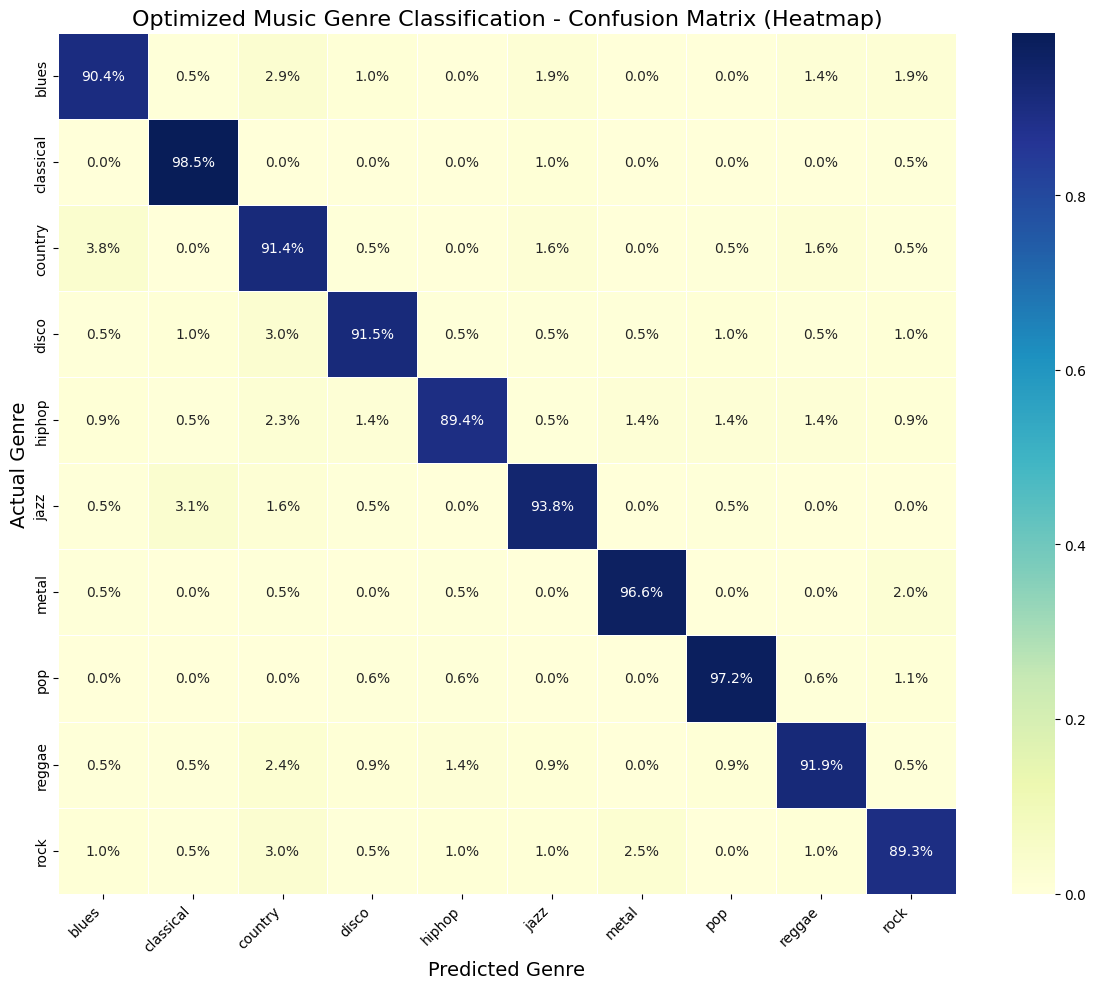

In [ ]:
# ==============================================================================
# VISUALIZATION: CONFUSION MATRIX HEATMAP
# ==============================================================================
# 9. Compute the confusion matrix
cm = confusion_matrix(y_test, preds)

# 10. Normalize the matrix (optional, but shows percentages for better comparison)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 11. Create a figure for the heatmap
plt.figure(figsize=(12, 10))

# 12. Plot the heatmap using Seaborn
# - annot=True displays the normalized percentages
# - cmap="YlGnBu" sets the color gradient (Yellow -> Green -> Blue)
# - fmt=".1%" displays values as percentages with one decimal
# - xticklabels/yticklabels use our actual genre names from LabelEncoder
sns.heatmap(
    cm_normalized,
    annot=True,
    cmap="YlGnBu",
    fmt=".1%",
    xticklabels=genre_names,
    yticklabels=genre_names,
    linewidths=.5 # Adds subtle lines between boxes for clarity
)

# 13. Label the plot
plt.title("Optimized Music Genre Classification - Confusion Matrix (Heatmap)", fontsize=16)
plt.xlabel("Predicted Genre", fontsize=14)
plt.ylabel("Actual Genre", fontsize=14)

# 14. Adjust layout so genre labels fit correctly
plt.xticks(rotation=45, ha='right') # Rotates x-axis labels by 45 degrees
plt.tight_layout()

# 15. Show the plot
plt.show()

In [ ]:
import joblib

# Save trained model
joblib.dump(model, "model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save label encoder
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']